In [3]:
title = "title"
horizon_length = 8
num_envs = 24576
csv_list = [
    "/home/mil/shitanda/CPO_NeurIPS2025/1_Neurips2025/figure_rebbuttal_0728/2_result/3/run_data/ShadowHand/0725-1-0.001-1-0.05-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/CPO_NeurIPS2025/1_Neurips2025/figure_rebbuttal_0728/2_result/3/run_data/ShadowHand/0725-1-0.001-1-0.1-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/CPO_NeurIPS2025/1_Neurips2025/figure_rebbuttal_0728/2_result/3/run_data/ShadowHand/0725-1-0.001-1-0.2-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m18s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/CPO_NeurIPS2025/1_Neurips2025/figure_rebbuttal_0728/2_result/3/run_data/ShadowHand/0725-1-0.001-1-0.5-0-0-5class-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h01m19s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/CPO_NeurIPS2025/1_Neurips2025/figure_rebbuttal_0728/2_result/3/run_data/ShadowHand/0725-SAPG-24576-plot_w_24576envs_mixed_expl_learn_param_lf_1p_30_07_07h02m42s_seed4/runs/importance_ratios.csv",
]

title_list = [
    "KL 0.05",
    "KL 0.1",
    "KL 0.2",
    "KL 0.5",
    "SAPG",
]


target_steps = [5e9]


(40205, 6)


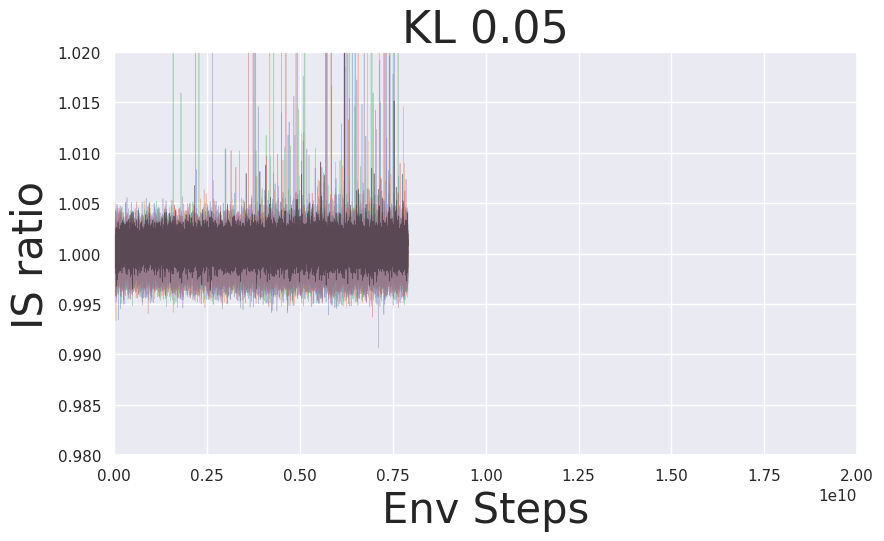

(36577, 6)


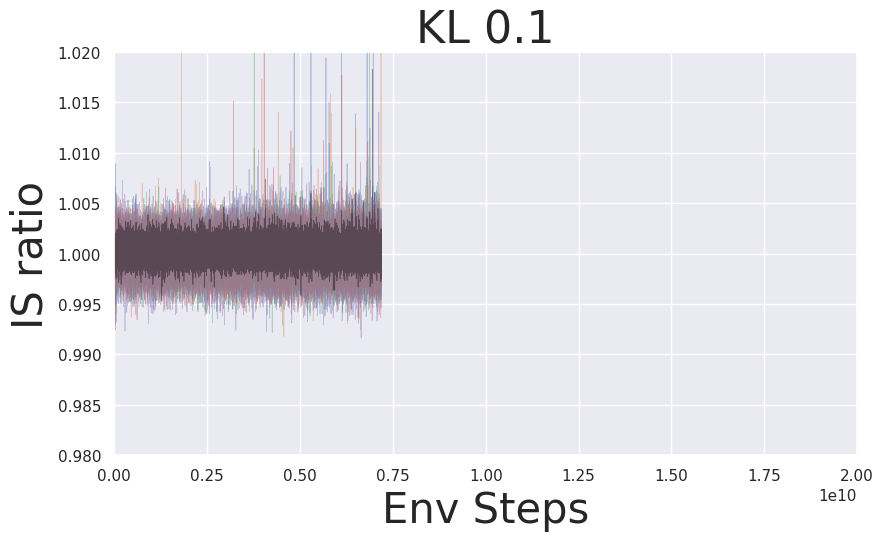

(40457, 6)


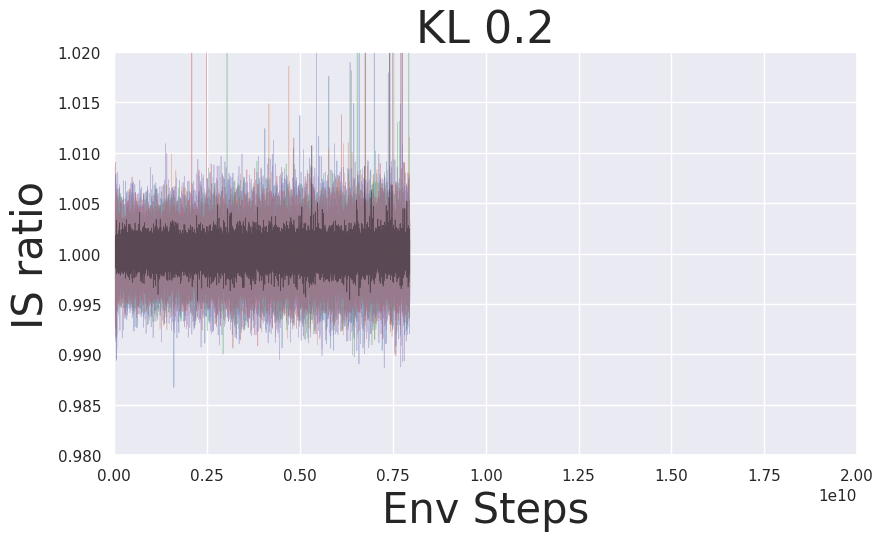

(39756, 6)


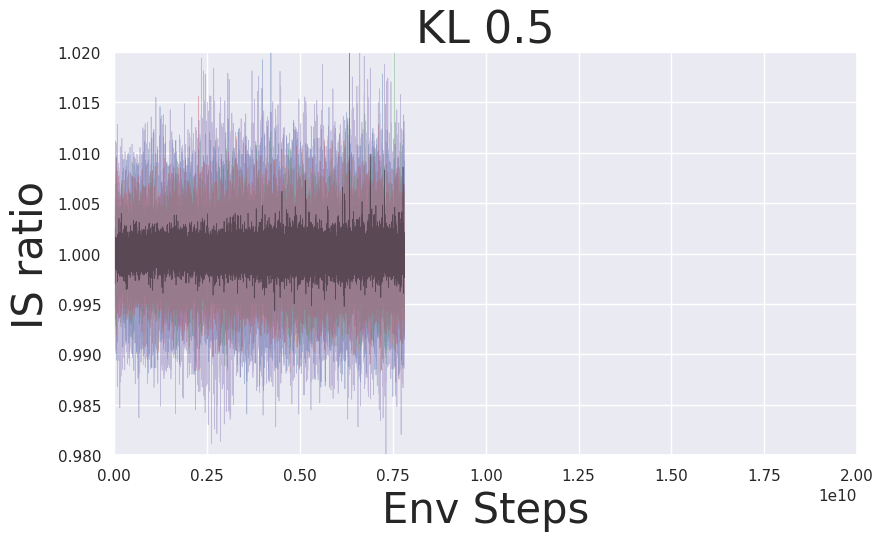

(52970, 6)


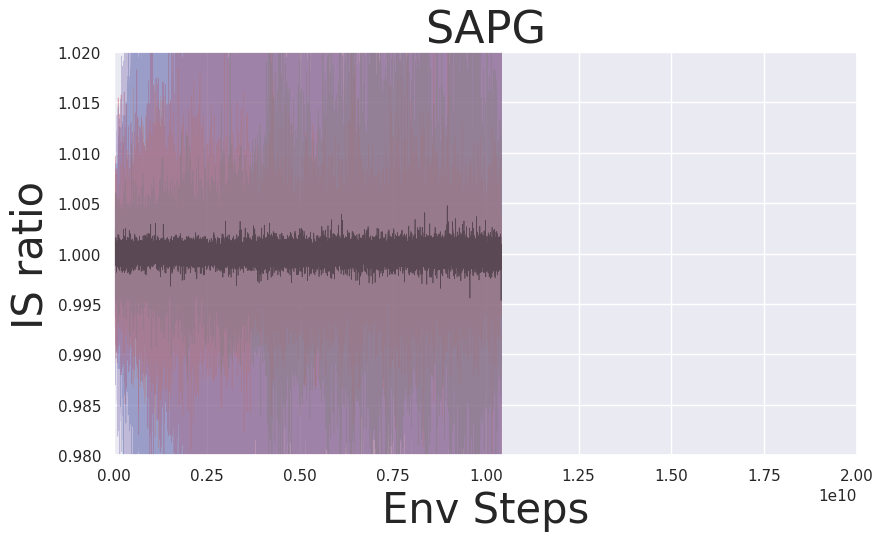

Target Step: 5000000000.0
KL 0.05 IS ratio at target step: [0.99995625 0.99906725 1.00079966 0.99991149 0.99949741 1.00137138]
deviation: [4.37498093e-05 9.32753086e-04 7.99655914e-04 8.85128975e-05
 5.02586365e-04 1.37138367e-03]
KL 0.1 IS ratio at target step: [1.00063145 1.0025965  0.99788857 1.00142384 0.99998432 1.0006175 ]
deviation: [6.31451607e-04 2.59649754e-03 2.11143494e-03 1.42383575e-03
 1.56760216e-05 6.17504120e-04]
KL 0.2 IS ratio at target step: [1.00072372 1.00078797 1.00232446 0.9977001  1.00286841 1.00049663]
deviation: [0.00072372 0.00078797 0.00232446 0.0022999  0.00286841 0.00049663]
KL 0.5 IS ratio at target step: [1.00580192 1.00001752 1.00434136 0.99926841 0.9963758  1.00010037]
deviation: [5.80191612e-03 1.75237656e-05 4.34136391e-03 7.31587410e-04
 3.62420082e-03 1.00374222e-04]
SAPG IS ratio at target step: [0.99677062 0.99735761 0.99945581 0.98441637 1.00631154 1.00049388]
deviation: [0.00322938 0.00264239 0.00054419 0.01558363 0.00631154 0.00049388]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np


def plot_is_ratio(csv_path, title, horizon_length, num_envs):
    """
    CSVファイルからIS比率を読み込み、グラフをプロットする関数
    """
    sns.set()
    # CSVファイルの読み込み
    csv_data = pd.read_csv(csv_path,)
    
    # データをNumPy配列に変換
    data_numpy = csv_data.to_numpy()
    data_numpy = csv_data.to_numpy().reshape(-1, 6)
    print(data_numpy.shape)

    # グラフの作成
    plt.figure(figsize=(9, 6))
    
    plt.xlabel("Env Steps", fontsize=30)
    plt.ylabel("IS ratio", fontsize=30)
    plt.title(title, fontsize=32)
    plt.grid(True)
    plt.xlim(0, 2e10)
    plt.ylim(0.98, 1.02)  # Allegro Hand

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    # N steps x 6のデータなので、6つの線をプロット
    for i in range(5):
        is_ratio = data_numpy[:, i]  # 1列目はEnv Stepsなので、2列目以降を使用
        x_steps = np.arange(len(is_ratio)) * horizon_length * num_envs  # 1Mステップごとにプロット
        plt.plot(x_steps, is_ratio, label=f"IS ratio {i+1}", linewidth=0.5, alpha=0.4)
    
    # 6個目(Leader自身のIS比率)は特別な色でプロット
    is_ratio_leader = data_numpy[:, 5]
    x_steps_leader = np.arange(len(is_ratio_leader)) * horizon_length * num_envs
    plt.plot(x_steps_leader, is_ratio_leader, label="IS ratio Leader", linewidth=0.5, color='black', alpha=0.4)
    
    #plt.legend(fontsize=20, loc='upper left')
    
    plt.show()

for csv_path, title in zip(csv_list, title_list):
    plot_is_ratio(csv_path, title, horizon_length, num_envs)
    
# target stepでのIS比率をプリント
for target_step in target_steps:
    print(f"Target Step: {target_step}")
    for csv_path, title in zip(csv_list, title_list):
        csv_data = pd.read_csv(csv_path)
        data_numpy = csv_data.to_numpy().reshape(-1, 6)
        
        # env stepをiteration stepに変換
        iteration_index = int(target_step // (horizon_length * num_envs))
        
        
        deviation = np.abs(data_numpy[iteration_index, :] - 1)
        print(title, "IS ratio at target step:", data_numpy[iteration_index, :])
        print("deviation:", deviation)
    


IndexError: index 1 is out of bounds for axis 1 with size 1

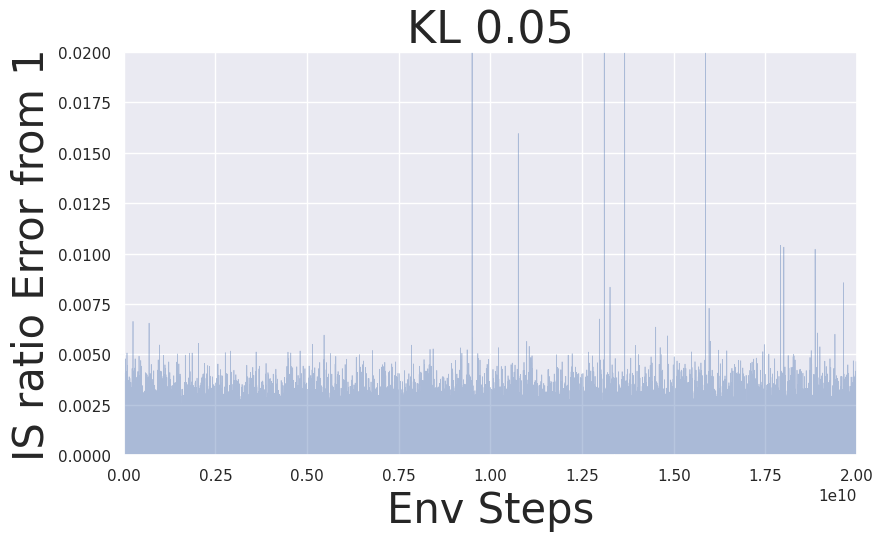

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np

def plot_is_ratio_error(csv_path, title, horizon_length, num_envs):
    """
    CSVファイルからIS比率を読み込み、1からの誤差をグラフでプロットする関数
    """
    # CSVファイルの読み込み
    csv_data = pd.read_csv(csv_path)
    
    # データをNumPy配列に変換
    data_numpy = csv_data.to_numpy()
    

    # グラフの作成
    plt.figure(figsize=(9, 6))
    
    plt.xlabel("Env Steps", fontsize=30)
    plt.ylabel("IS ratio Error from 1", fontsize=30)
    plt.title(title, fontsize=32)
    plt.grid(True)
    plt.xlim(0, 2e10)
    plt.ylim(0, 0.02)  # エラーの範囲に調整

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    # 最初の5つのIS比率のエラーをプロット
    for i in range(5):
        is_ratio = data_numpy[:, i]
        is_error = np.abs(is_ratio - 1.0)  # 1からの絶対誤差
        x_steps = np.arange(len(is_error)) * horizon_length * num_envs
        plt.plot(x_steps, is_error, label=f"IS ratio {i+1} Error", linewidth=0.5, alpha=0.4)
    
    # 6個目(Leader自身のIS比率)のエラーは特別な色でプロット
    is_ratio_leader = data_numpy[:, 5]
    is_error_leader = np.abs(is_ratio_leader - 1.0)
    x_steps_leader = np.arange(len(is_error_leader)) * horizon_length * num_envs
    plt.plot(x_steps_leader, is_error_leader, label="IS ratio Leader Error", linewidth=0.5, color='black', alpha=0.4)
    
    #plt.legend(fontsize=20, loc='upper left')
    
    plt.show()

for csv_path, title in zip(csv_list, title_list):
    plot_is_ratio_error(csv_path, title, horizon_length, num_envs)